# Lab 4 – Intensity Transformations and Filtering (Spatial Domain)

## Task 1: Thresholding

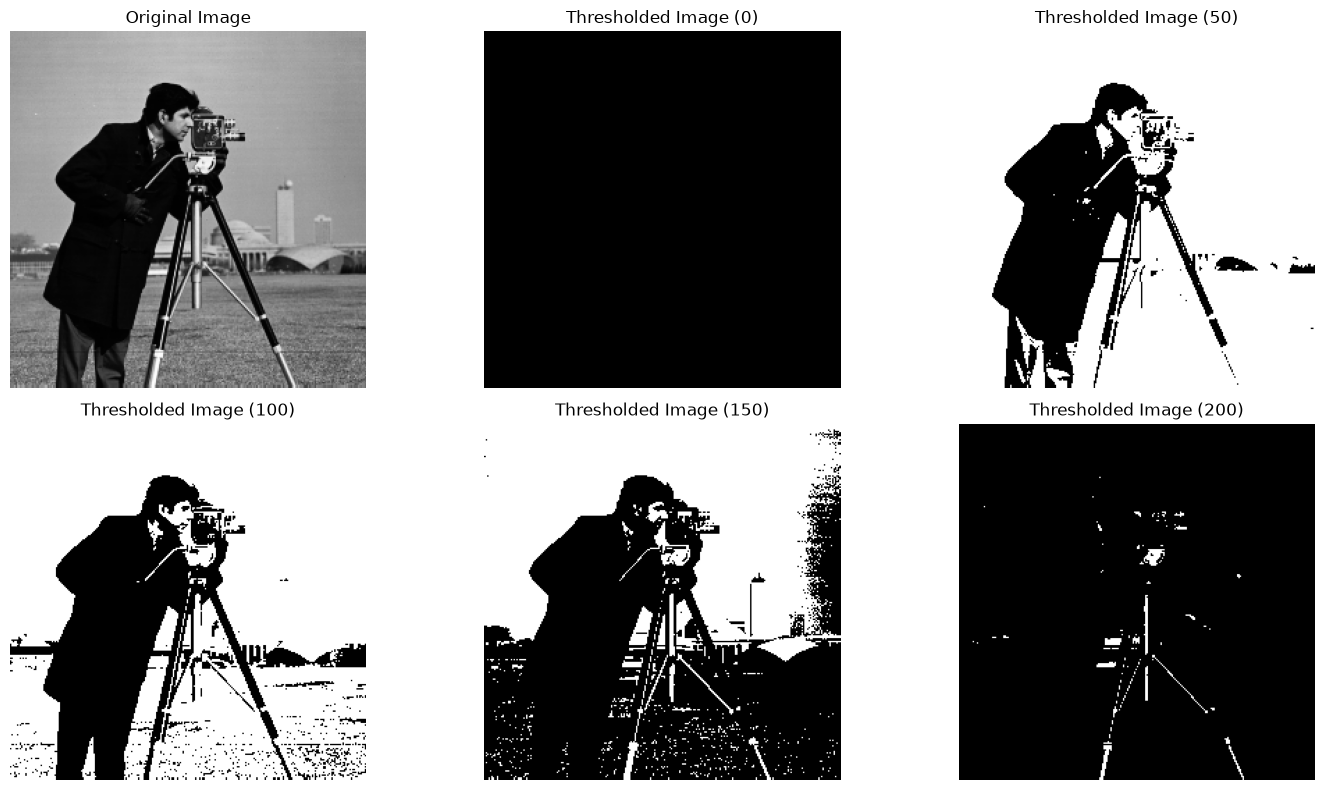

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float
from skimage.exposure import match_histograms

# Parrot.png is not in the repo, so cameraman.tiff is used instead
img = cv2.imread('../images/cameraman.tiff', cv2.IMREAD_GRAYSCALE)
threshold_values = [0, 50, 100, 150, 200]

plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
for i, t in enumerate(threshold_values, 2):
    ret, thresh = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, i); plt.imshow(thresh, cmap='gray'); plt.title(f'Thresholded Image ({t})'); plt.axis('off')
plt.tight_layout(); plt.show()

## Task 2: Histogram Processing

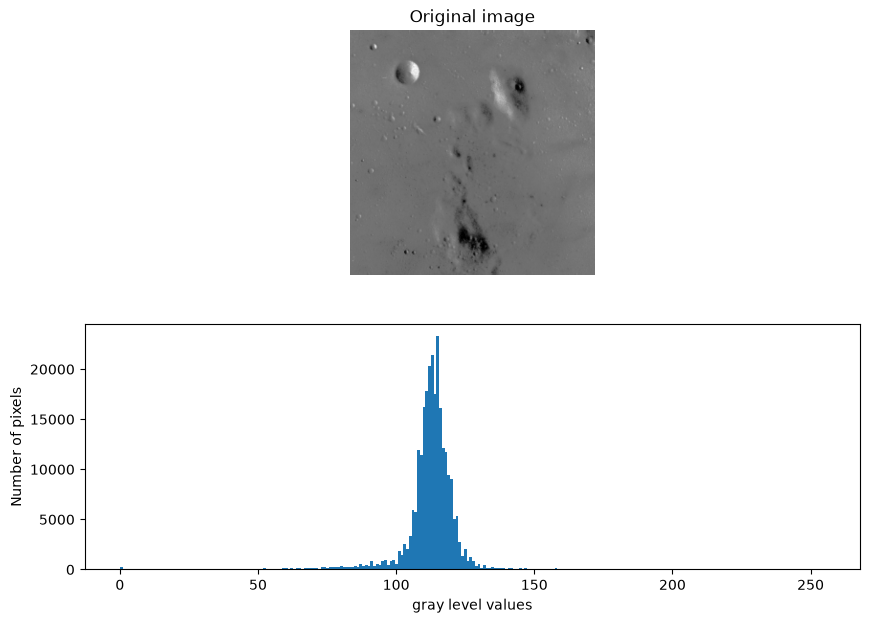

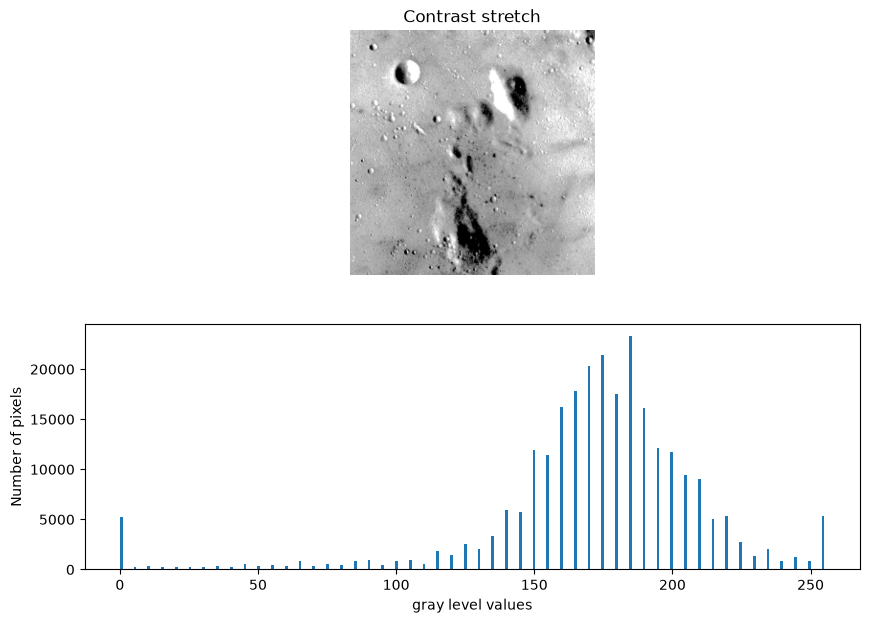

In [2]:
img = data.moon()

# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

def show_with_hist(im, title):
    fig = plt.figure(figsize=(10, 7))
    fig.add_subplot(2, 1, 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.axis('off'); plt.title(title)
    fig.add_subplot(2, 1, 2)
    plt.hist(im.flat, bins=256, range=(0, 255))
    plt.xlabel('gray level values'); plt.ylabel('Number of pixels')
    plt.show()

show_with_hist(img, 'Original image')
show_with_hist(img_rescale, 'Contrast stretch')

# Assessment
## Task 1: Rescale to the 3rd–80th percentiles

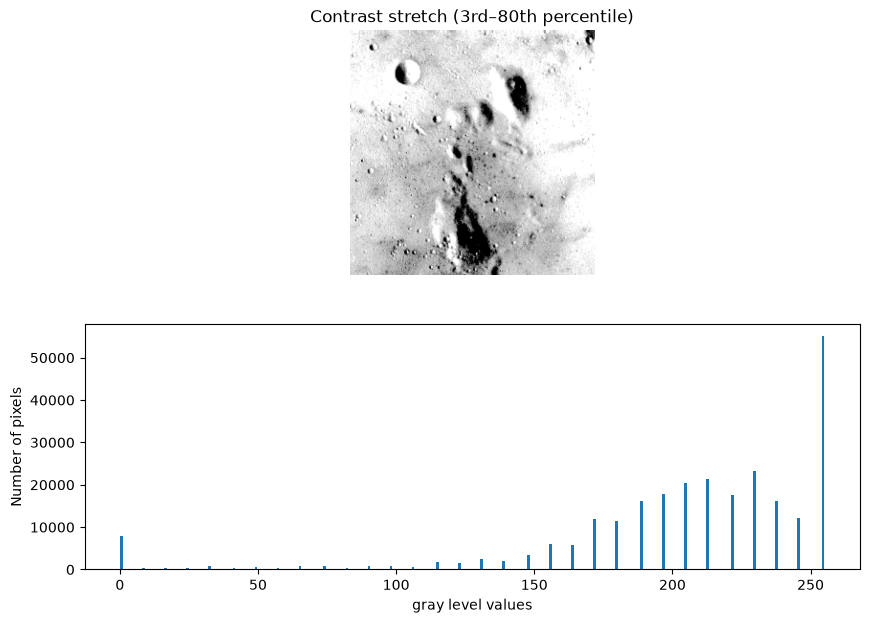

In [3]:
p3, p80 = np.percentile(img, (3, 80))
img_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
show_with_hist(img_3_80, 'Contrast stretch (3rd–80th percentile)')

## Task 2: Histogram equalization

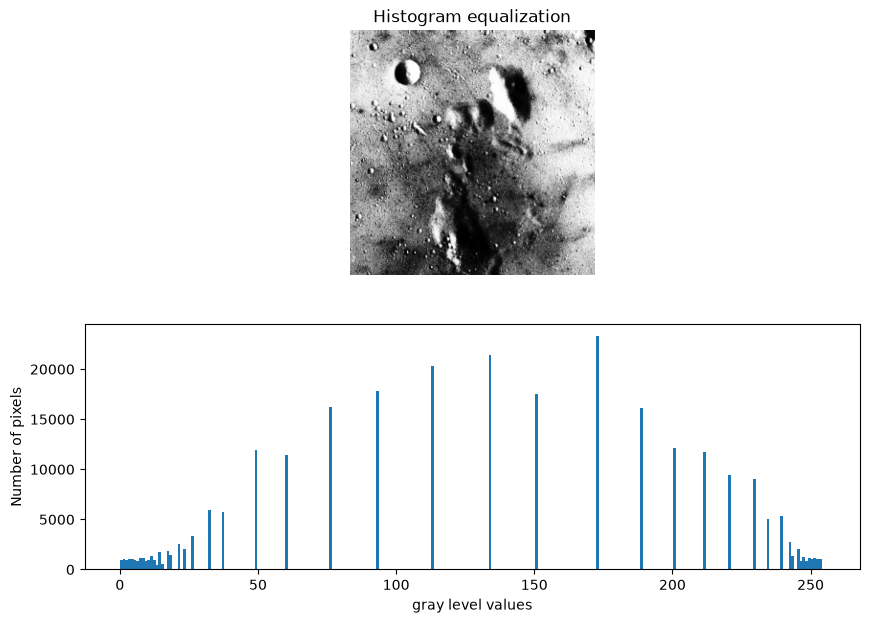

In [4]:
img_eq = (exposure.equalize_hist(img) * 255).astype(np.uint8)
show_with_hist(img_eq, 'Histogram equalization')

## Task 3: Histogram matching (rocket as reference, Chelsea as image)

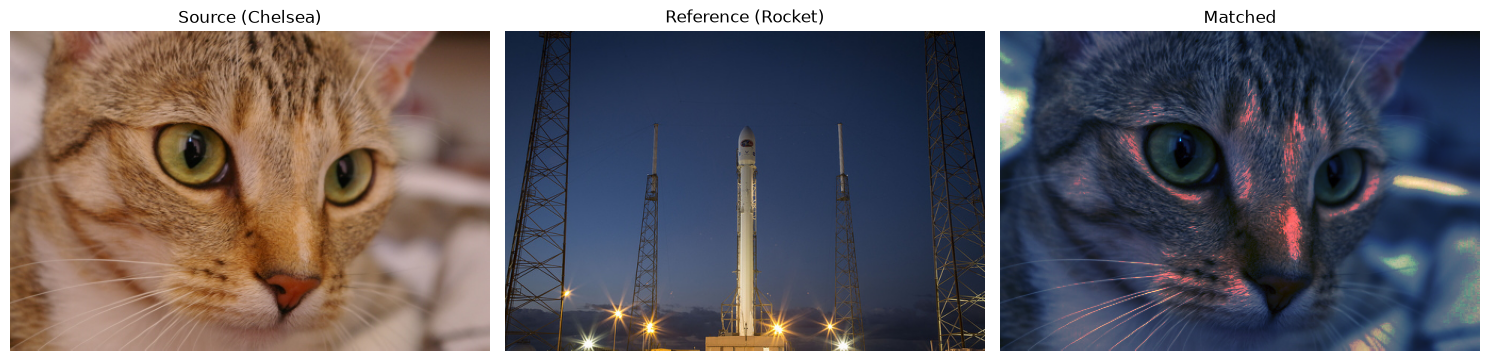

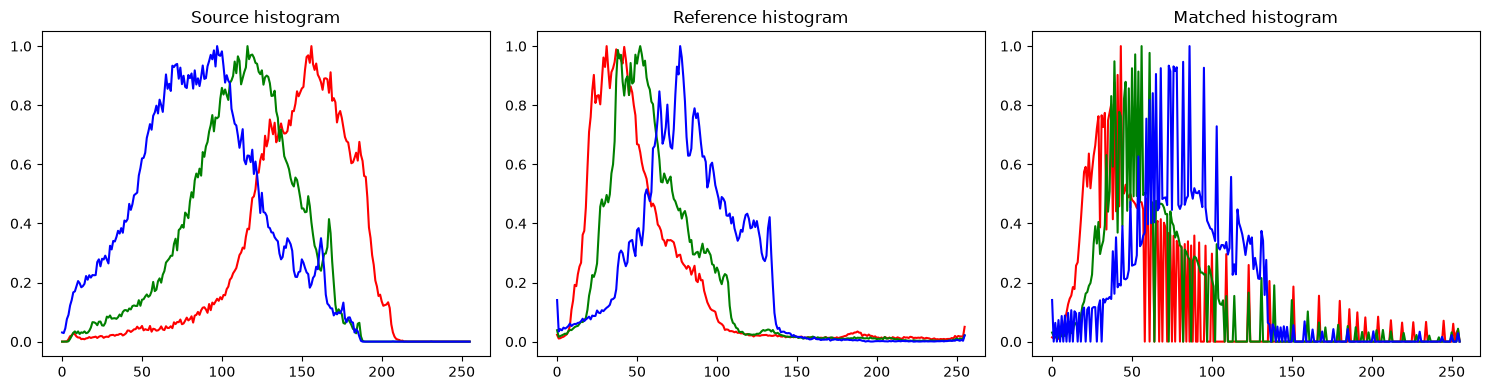

In [5]:
reference = data.rocket()
image = data.chelsea()
matched = match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, t in zip(axes, (image, reference, matched), ('Source (Chelsea)', 'Reference (Rocket)', 'Matched')):
    ax.imshow(im); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for c, color in enumerate(('red', 'green', 'blue')):
    for ax, im in zip(axes, (image, reference, matched)):
        hist, bins = exposure.histogram(im[..., c], source_range='dtype')
        ax.plot(bins, hist / hist.max(), color=color)
for ax, t in zip(axes, ('Source', 'Reference', 'Matched')):
    ax.set_title(t + ' histogram')
plt.tight_layout(); plt.show()